GENERATING KOLMOGOROV COMPRESSION VISUAL...
[1/3] Running Golden-Fano Automaton (Base-10)...
[2/3] Setting up layout...


/tmp/ipykernel_6309/3138896797.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])



[3/3] Saved: kolmogorov_compression_visual.png


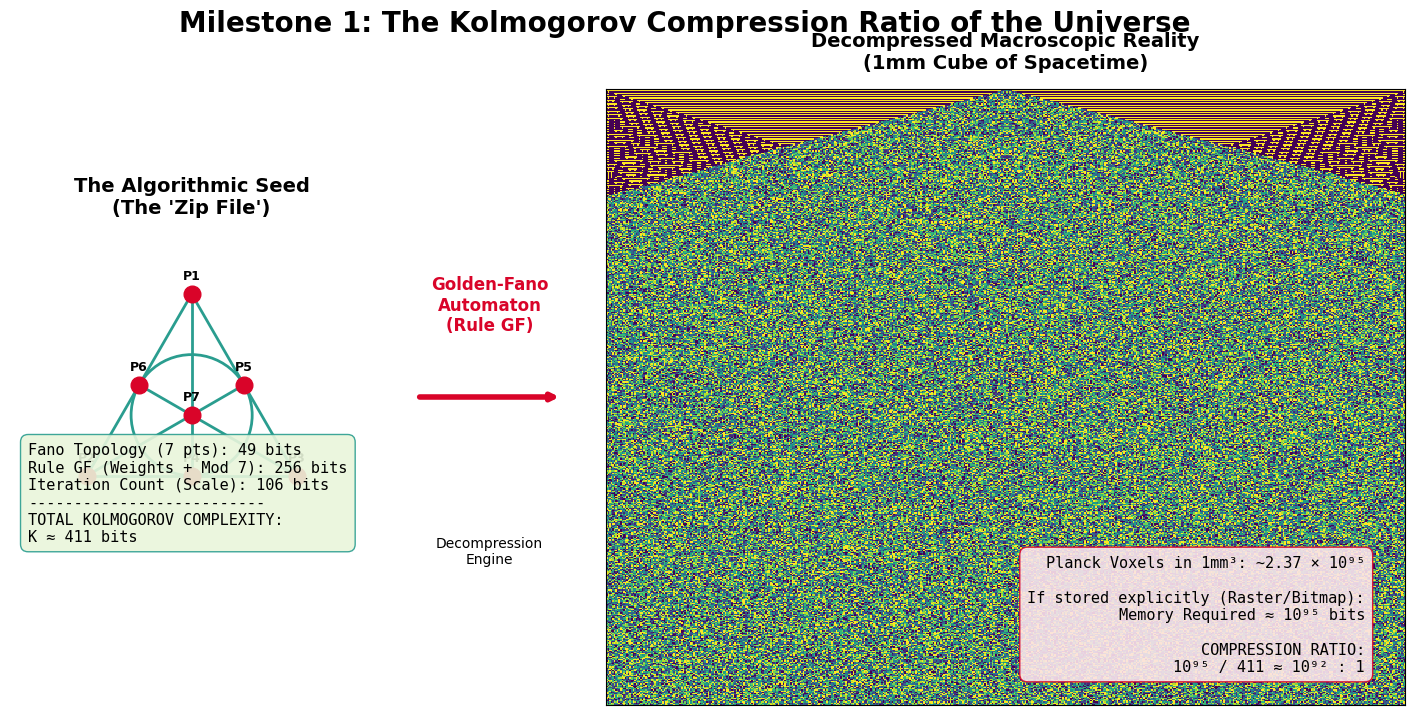


VISUAL COMPLETE


In [2]:
"""
kolmogorov_compression_visual.py
================================
Visualizes Milestone 1: The Kolmogorov Compression Ratio of the Universe.
Contrasts the tiny algorithmic seed (411 bits) with the massive explicit storage requirement (~10^95 bits) for a 1mm cube of spacetime.

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("=" * 70)
print("GENERATING KOLMOGOROV COMPRESSION VISUAL...")
print("=" * 70)

# =============================================================================
# 1. THE GOLDEN-FANO AUTOMATON (To represent the "Decompressed" Spacetime)
# =============================================================================
def run_fano_ca_visual(base, steps=512, width=512):
    """Runs the CA to generate a dense texture of spacetime."""
    grid = np.zeros((steps, width), dtype=int)
    grid[0, width // 2] = 1  # Seed

    W = np.array([1, 2, 3, 5, 3, 2, 1])
    reserved_state = base - 1
    active_modulus = base - 1

    for t in range(1, steps):
        padded_row = np.pad(grid[t-1], (3, 3), mode='constant', constant_values=0)
        weighted_sum = np.zeros(width, dtype=int)
        for i in range(7):
            weighted_sum += W[i] * padded_row[i : i + width]

        reserved_mask = (weighted_sum % 7 == 0)
        new_states = weighted_sum % active_modulus
        new_states[reserved_mask] = reserved_state
        grid[t] = new_states

    return grid

# =============================================================================
# 2. DRAWING THE FANO PLANE (The "Seed")
# =============================================================================
def draw_fano_plane(ax):
    """Draws a geometrically accurate Fano Plane."""
    # Points coordinates
    pts = {
        'P1': (0, 1),
        'P2': (-0.866, -0.5),
        'P3': (0.866, -0.5),
        'P4': (0, -0.5),
        'P5': (0.433, 0.25),
        'P6': (-0.433, 0.25),
        'P7': (0, 0)
    }

    # Lines (7 lines: 3 triangle edges, 3 altitudes, 1 inscribed circle)
    lines = [
        ('P1', 'P2'), ('P1', 'P3'), ('P2', 'P3'),  # Triangle edges
        ('P1', 'P4'), ('P2', 'P5'), ('P3', 'P6')   # Altitudes through center
    ]

    # Draw Lines
    for p1, p2 in lines:
        x = [pts[p1][0], pts[p2][0]]
        y = [pts[p1][1], pts[p2][1]]
        ax.plot(x, y, color='#2a9d8f', linewidth=2, zorder=1)

    # Draw Circle (The 7th line)
    circle = plt.Circle((0, 0), 0.5, color='#2a9d8f', fill=False, linewidth=2, zorder=1)
    ax.add_patch(circle)

    # Draw Points
    for name, (x, y) in pts.items():
        ax.plot(x, y, 'o', color='#d90429', markersize=12, zorder=2)
        ax.text(x, y+0.15, name, ha='center', va='center', fontsize=9, fontweight='bold', color='black')

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.2, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')

# =============================================================================
# 3. MAIN VISUALIZATION
# =============================================================================
print("[1/3] Running Golden-Fano Automaton (Base-10)...")
grid = run_fano_ca_visual(base=10, steps=512, width=512)

print("[2/3] Setting up layout...")
fig = plt.figure(figsize=(18, 8))
fig.suptitle("Milestone 1: The Kolmogorov Compression Ratio of the Universe", fontsize=20, fontweight='bold', y=0.98)

# GridSpec for asymmetric layout: [Seed] [Arrow] [Decompressed Spacetime]
gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.4, 2.2], wspace=0.1)

# --- LEFT PANEL: THE SEED (The "Zip File") ---
ax1 = fig.add_subplot(gs[0])
draw_fano_plane(ax1)
ax1.set_title("The Algorithmic Seed\n(The 'Zip File')", fontsize=14, fontweight='bold', pad=15)

# Add text box for the math
textstr = (
    "Fano Topology (7 pts): 49 bits\n"
    "Rule GF (Weights + Mod 7): 256 bits\n"
    "Iteration Count (Scale): 106 bits\n"
    "--------------------------\n"
    "TOTAL KOLMOGOROV COMPLEXITY:\n"
    "K ≈ 411 bits"
)
props = dict(boxstyle='round,pad=0.5', facecolor='#e9f5db', edgecolor='#2a9d8f', alpha=0.9)
ax1.text(0.05, 0.05, textstr, transform=ax1.transAxes, fontsize=11, verticalalignment='bottom', bbox=props, family='monospace')

# --- MIDDLE PANEL: THE ENGINE ---
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')
# Draw a large arrow
ax2.annotate('', xy=(1.0, 0.5), xytext=(0.0, 0.5), xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='#d90429', lw=4))
ax2.text(0.5, 0.65, 'Golden-Fano\nAutomaton\n(Rule GF)', ha='center', va='center', fontsize=12, fontweight='bold', color='#d90429')
ax2.text(0.5, 0.25, 'Decompression\nEngine', ha='center', va='center', fontsize=10, color='black')

# --- RIGHT PANEL: THE DECOMPRESSED REALITY (CORREGIDA A COLOR) ---
ax3 = fig.add_subplot(gs[2])

# CAMBIO AQUÍ: Usamos 'grid' original en lugar de 'binary_grid' y cambiamos el cmap a 'viridis'
ax3.imshow(grid, cmap='viridis', aspect='auto', interpolation='nearest')

ax3.set_title("Decompressed Macroscopic Reality\n(1mm Cube of Spacetime)", fontsize=14, fontweight='bold', pad=15)
ax3.set_xticks([])
ax3.set_yticks([])

# Add text box for the massive number
textstr2 = (
    "Planck Voxels in 1mm³: ~2.37 × 10⁹⁵\n\n"
    "If stored explicitly (Raster/Bitmap):\n"
    "Memory Required ≈ 10⁹⁵ bits\n\n"
    "COMPRESSION RATIO:\n"
    "10⁹⁵ / 411 ≈ 10⁹² : 1"
)
props2 = dict(boxstyle='round,pad=0.5', facecolor='#fce4ec', edgecolor='#d90429', alpha=0.9)
ax3.text(0.95, 0.05, textstr2, transform=ax3.transAxes, fontsize=11, verticalalignment='bottom', horizontalalignment='right', bbox=props2, family='monospace')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("kolmogorov_compression_visual.png", dpi=300, bbox_inches='tight')
print("\n[3/3] Saved: kolmogorov_compression_visual.png")
plt.show()

print("\n" + "=" * 70)
print("VISUAL COMPLETE")
print("=" * 70)
